# Electric Vehicle Data Analysis: Adoption Trends and Market Insights

## Objective:

The objective of this project is to analyze the Electric Vehicle (EV) population data to understand trends in electric vehicle adoption across different regions, vehicle types, and manufacturers. The analysis aims to identify growth patterns in EV usage, the most popular EV brands and models, geographic distribution of electric vehicles, and factors influencing EV adoption such as electric range and CAFV eligibility. The insights generated from this analysis can help policymakers, automotive companies, and energy providers understand EV market trends and make data-driven decisions to support sustainable transportation.

In [1]:
import pandas as pd
import numpy as  np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv(r"C:\Users\Admin\Downloads\Electric_Vehicle_Population_Data.csv")

In [5]:
df.head(5)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,JN1AZ0CP5C,Stevens,Colville,WA,99114.0,2012,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,7.0,153331706,POINT (-117.90454 48.54657),AVISTA CORP,5.306595e+10
1,JTMABABA7P,Yakima,Yakima,WA,98903.0,2023,SUBARU,SOLTERRA,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,15.0,253586308,POINT (-120.71847 46.55029),PACIFICORP,5.307700e+10
2,1N4AZ1CP1J,King,Seattle,WA,98122.0,2018,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,151.0,37.0,333135022,POINT (-122.31009 47.60803),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5UX43EU09S,Kitsap,Poulsbo,WA,98370.0,2025,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,40.0,23.0,267525737,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC,5.303594e+10
4,3C3CFFGE5F,Thurston,Yelm,WA,98597.0,2015,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,87.0,2.0,474468501,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279780 entries, 0 to 279779
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         279780 non-null  object 
 1   County                                             279756 non-null  object 
 2   City                                               279756 non-null  object 
 3   State                                              279780 non-null  object 
 4   Postal Code                                        279756 non-null  float64
 5   Model Year                                         279780 non-null  int64  
 6   Make                                               279780 non-null  object 
 7   Model                                              279780 non-null  object 
 8   Electric Vehicle Type                              279780 non-null  object

In [7]:
df.shape

(279780, 16)

In [8]:
df.describe()

,Postal Code,Model Year,Electric Range,Legislative District,DOL Vehicle ID,2020 Census Tract
count,279756.000000,279780.000000,279769.000000,279080.000000,2.797800e+05,2.797560e+05
mean,98176.111447,2022.074072,39.172256,28.827841,2.462994e+08,5.297189e+10
std,2577.398040,3.059852,78.230356,14.908133,6.346205e+07,1.636194e+09
min,1030.000000,1999.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2021.000000,0.000000,17.000000,2.213867e+08,5.303301e+10
50%,98133.000000,2023.000000,0.000000,32.000000,2.629453e+08,5.303303e+10
75%,98382.000000,2024.000000,32.000000,42.000000,2.790832e+08,5.305394e+10
max,99517.000000,2027.000000,337.000000,49.000000,4.791150e+08,6.601095e+10


In [9]:
# if we statistical summary for categorical column too
df.describe(include="all")

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
count,279780,279756,279756,279780,279756.000000,279780.000000,279780,279780,279780,279780,279769.000000,279080.000000,2.797800e+05,279671,279756,2.797560e+05
unique,17072,253,894,52,NaN,NaN,47,187,2,3,NaN,NaN,NaN,1115,77,NaN
top,7SAYGDEE7P,King,Seattle,WA,NaN,NaN,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,NaN,NaN,NaN,POINT (-122.13158 47.67858),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),NaN
freq,1187,138130,43250,279093,NaN,NaN,114847,60035,223884,177937,NaN,NaN,NaN,6776,99568,NaN
mean,NaN,NaN,NaN,NaN,98176.111447,2022.074072,NaN,NaN,NaN,NaN,39.172256,28.827841,2.462994e+08,NaN,NaN,5.297189e+10
std,NaN,NaN,NaN,NaN,2577.398040,3.059852,NaN,NaN,NaN,NaN,78.230356,14.908133,6.346205e+07,NaN,NaN,1.636194e+09
min,NaN,NaN,NaN,NaN,1030.000000,1999.000000,NaN,NaN,NaN,NaN,0.000000,1.000000,4.385000e+03,NaN,NaN,1.001020e+09
25%,NaN,NaN,NaN,NaN,98052.000000,2021.000000,NaN,NaN,NaN,NaN,0.000000,17.000000,2.213867e+08,NaN,NaN,5.303301e+10
50%,NaN,NaN,NaN,NaN,98133.000000,2023.000000,NaN,NaN,NaN,NaN,0.000000,32.000000,2.629453e+08,NaN,NaN,5.303303e+10
75%,NaN,NaN,NaN,NaN,98382.000000,2024.000000,NaN,NaN,NaN,NaN,32.000000,42.000000,2.790832e+08,NaN,NaN,5.305394e+10


## Cleaning

In [10]:
# Total Null Value

In [11]:
df.isnull().sum()

VIN (1-10)                                             0
County                                                24
City                                                  24
State                                                  0
Postal Code                                           24
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                        11
Legislative District                                 700
DOL Vehicle ID                                         0
Vehicle Location                                     109
Electric Utility                                      24
2020 Census Tract                                     24
dtype: int64

In [12]:
columns=["County","City","Postal Code","Electric Utility","2020 Census Tract"]

for col in columns:
    df[col]=df[col].fillna(df[col].mode()[0])

    #Mode imputation is used for categorical variables because it replaces missing values
    #with the most frequently occurring category, preserving the dataset's distribution.
    

In [13]:
df["Electric Range"]=df["Electric Range"].fillna(df["Electric Range"].median())
#Median imputation is preferred for numerical data with possible outliers because 
#it represents the central tendency without being affected by extreme values

In [14]:
df["Vehicle Location"]=df["Vehicle Location"].fillna("Unknown")
#For location-based textual data where estimation is unreliable, assigning a placeholder such 
#as "Unknown" prevents incorrect data assumptions.

In [15]:
df.drop(columns=["Legislative District"],inplace=True)
#Columns with a high percentage of missing values can introduce bias 
#during imputation, therefore dropping them preserves data integrity.

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.columns=df.columns.str.lower()
df.columns=df.columns.str.replace(" ","_")

In [18]:
df.rename(columns={"electric_vehicle_type":"EV_type"},inplace=True)
#this  will mark queries easier later

In [19]:
df.columns

Index(['vin_(1-10)', 'county', 'city', 'state', 'postal_code', 'model_year',
       'make', 'model', 'EV_type',
       'clean_alternative_fuel_vehicle_(cafv)_eligibility', 'electric_range',
       'dol_vehicle_id', 'vehicle_location', 'electric_utility',
       '2020_census_tract'],
      dtype='object')

### Manufacturers

In [20]:
df["make"].unique()

array(['NISSAN', 'SUBARU', 'BMW', 'FIAT', 'JEEP', 'TESLA', 'VOLVO', 'KIA',
       'CHEVROLET', 'MINI', 'AUDI', 'FORD', 'MITSUBISHI', 'FISKER',
       'HYUNDAI', 'CHRYSLER', 'DODGE', 'PORSCHE', 'TOYOTA', 'LEXUS',
       'ALFA ROMEO', 'MAZDA', 'JAGUAR', 'RIVIAN', 'VOLKSWAGEN', 'HONDA',
       'LINCOLN', 'GENESIS', 'LUCID', 'MERCEDES-BENZ', 'TH!NK', 'GMC',
       'ACURA', 'POLESTAR', 'CADILLAC', 'SMART', 'VINFAST', 'LAND ROVER',
       'LAMBORGHINI', 'ROLLS-ROYCE', 'BRIGHTDROP', 'RAM',
       'WHEEGO ELECTRIC CARS', 'MULLEN AUTOMOTIVE INC.', 'AZURE DYNAMICS',
       'BENTLEY', 'MASERATI'], dtype=object)

In [21]:
df["make"].value_counts()

make
TESLA                     114847
CHEVROLET                  19261
NISSAN                     16164
FORD                       15347
KIA                        13938
TOYOTA                     11827
BMW                        11607
HYUNDAI                    10357
RIVIAN                      8863
VOLKSWAGEN                  7449
VOLVO                       7350
JEEP                        6927
AUDI                        5937
CHRYSLER                    3904
MERCEDES-BENZ               3338
HONDA                       3093
SUBARU                      2717
CADILLAC                    2434
PORSCHE                     2004
POLESTAR                    1609
LEXUS                       1557
MAZDA                       1533
MITSUBISHI                  1267
MINI                        1230
FIAT                         854
DODGE                        828
LUCID                        703
GMC                          540
GENESIS                      504
LINCOLN                      443
ACURA

In [22]:
df.dtypes

vin_(1-10)                                            object
county                                                object
city                                                  object
state                                                 object
postal_code                                          float64
model_year                                             int64
make                                                  object
model                                                 object
EV_type                                               object
clean_alternative_fuel_vehicle_(cafv)_eligibility     object
electric_range                                       float64
dol_vehicle_id                                         int64
vehicle_location                                      object
electric_utility                                      object
2020_census_tract                                    float64
dtype: object

In [23]:
df.drop(columns=["vin_(1-10)"],inplace=True)

In [24]:
df.shape

(279780, 14)

### Count Electric Vehicle Types

In [25]:
df["EV_type"].value_counts()

EV_type
Battery Electric Vehicle (BEV)            223884
Plug-in Hybrid Electric Vehicle (PHEV)     55896
Name: count, dtype: int64

In [26]:
# BEV dominate the market compare to Plug-in Hybrid Electric Vehicle

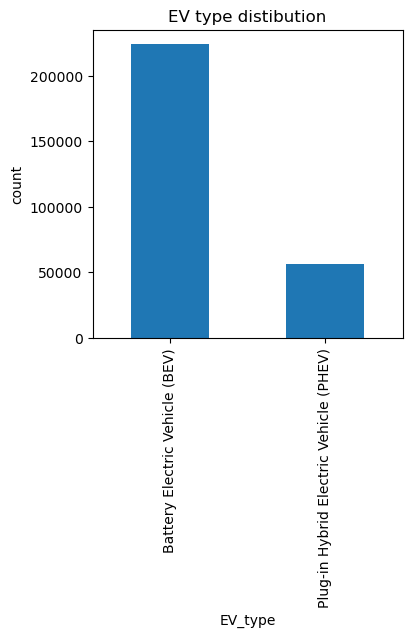

NameError: name 'container' is not defined

In [27]:
plt.figure(figsize=(4,4))
er=df["EV_type"].value_counts().plot(kind="bar")
plt.title("EV type distibution")
plt.xlabel("EV_type")
plt.ylabel("count")
plt.show()

for bar in er.containers:
    er.bar_label(container)

### Top EV Manufacturers

In [ ]:
df["make"].value_counts().head(10)

In [ ]:
# The analysis shows that a few manufacturers dominate the electric vehicle market . Companies such as Tesla,Nissan , Chevrolet
#have highest number of registered electric vehicles in the dataset.

### EV Adoption by Year

In [28]:
df["model_year"].value_counts().sort_index()

model_year
1999        2
2000        7
2002        1
2003        1
2008       19
2010       22
2011      578
2012     1373
2013     3951
2014     3215
2015     4412
2016     5097
2017     8467
2018    14118
2019    10853
2020    12090
2021    20943
2022    30006
2023    60261
2024    49947
2025    37010
2026    17405
2027        2
Name: count, dtype: int64

### EV Adoption Trend Chart

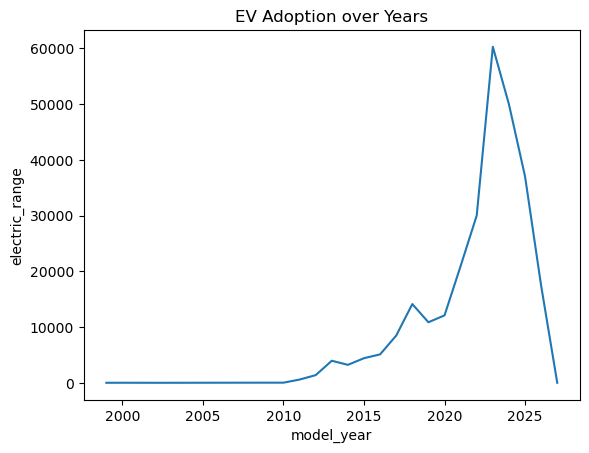

In [29]:
df["model_year"].value_counts().sort_index().plot(kind="line")
plt.title("EV Adoption over Years")
plt.xlabel("model_year")
plt.ylabel("electric_range")
plt.show()

In [30]:
# this graph represent that in 2025 more range are been  launched.Electric Vehicle adoption has increased singnificantly over recent years indicating 
#a groeing shift toward sustinable transportation.

In [31]:
# EV adoption has increased significantly after 2018 this trend suggest strong market growth  and increasing consumer acceptance of EV technology.

### Top cities with EV

In [32]:
df["city"].value_counts().head(10)

city
Seattle      43274
Bellevue     13685
Vancouver    10395
Redmond       9606
Bothell       9239
Kirkland      7978
Sammamish     7798
Renton        7647
Olympia       6510
Tacoma        6072
Name: count, dtype: int64

In [33]:
df["county"].value_counts().head(10)

county
King         138154
Snohomish     34919
Pierce        22906
Clark         17217
Thurston      10134
Kitsap         9486
Spokane        7834
Whatcom        6829
Benton         3990
Skagit         3303
Name: count, dtype: int64

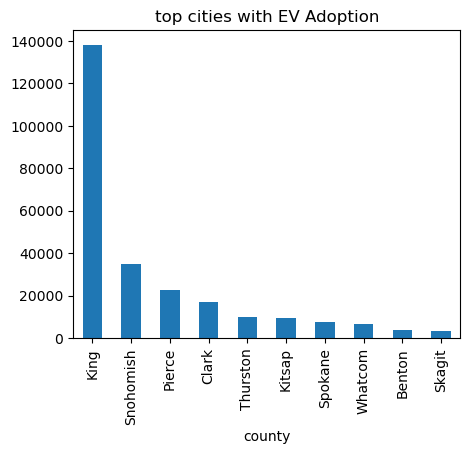

In [34]:
plt.figure(figsize=(5,4))
df["county"].value_counts().head(10).plot(kind="bar")
plt.title("top cities with EV Adoption")
plt.show()

### Average Electric Range by Manufaturer

In [35]:
df.groupby("make")["electric_range"].mean().sort_values(ascending=False)

make
JAGUAR                    168.420382
WHEEGO ELECTRIC CARS      100.000000
TH!NK                     100.000000
CHEVROLET                  77.942474
FIAT                       73.745902
NISSAN                     63.680525
SMART                      61.605150
AZURE DYNAMICS             56.000000
TESLA                      51.346888
LAND ROVER                 51.000000
PORSCHE                    48.859281
AUDI                       36.742294
ALFA ROMEO                 33.000000
BENTLEY                    33.000000
MITSUBISHI                 32.641673
CHRYSLER                   32.164703
KIA                        28.272564
POLESTAR                   27.803605
TOYOTA                     27.798343
DODGE                      27.362319
BMW                        26.994831
MAZDA                      25.590998
LINCOLN                    24.674944
LEXUS                      22.725112
LAMBORGHINI                22.423077
JEEP                       21.620615
VOLVO                      17.998

In [36]:
# Jagure has the highest electric range reflecting difference in battery  technology and vehical design strategies.

I performed exploratory data analysis using Python to understand patterns in the dataset. I analyzed EV adoption trends by model year, identified the most popular manufacturers and models, examined vehicle type distribution, and explored geographic EV adoption across cities and counties. I also used visualizations to identify trends and patterns in the electric vehicle market.

In [37]:
df.to_csv("EV_Data_Cleaned.csv", index=False)